## Instalar dependencias e importar librerias

In [1]:
try:
    import google.colab  # type: ignore
    IS_COLAB = True
except ImportError:
    IS_COLAB = False

if IS_COLAB:
    !pip install ultralytics opencv-python roboflow
else:
    print("Ejecucion local detectada. Instala dependencias en tu entorno antes de continuar.")
    print("Sugerencia: uv add ultralytics opencv-python roboflow jupyter ipykernel")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 31.2 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 184.0/184.0 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 21.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 89.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 146.0 MB/s eta 0:00:0000:01
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11


In [2]:
import os
import cv2
import torch
import shutil
from pathlib import Path
from ultralytics import YOLO

# Cambia solo estas variables si quieres reutilizar el notebook en otro entorno.
LOCAL_PROJECT_ROOT = Path("/home/fr4mes/unab/clase-ciencia-de-datos")
LOCAL_DATASET_DIR = LOCAL_PROJECT_ROOT / "dataset"
COLAB_DATASET_DIR = Path("/content/dataset")
DOWNLOADED_DATASET_NAME = "ppe-factory-1"
MODEL_NAME = "yolov8n.pt"

DATASET_DIR = COLAB_DATASET_DIR if IS_COLAB else LOCAL_DATASET_DIR
DATA_YAML = DATASET_DIR / "data.yaml"
TEST_IMAGES_DIR = DATASET_DIR / "test" / "images"
DOWNLOAD_DIR = (Path("/content") if IS_COLAB else Path.cwd()) / DOWNLOADED_DATASET_NAME

print(f"IS_COLAB: {IS_COLAB}")
print(f"DATASET_DIR: {DATASET_DIR}")
print(f"DOWNLOAD_DIR: {DOWNLOAD_DIR}")
print(f"DATA_YAML: {DATA_YAML}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
IS_COLAB: True
DATASET_DIR: /content/dataset
DOWNLOAD_DIR: /content/ppe-factory-1
DATA_YAML: /content/dataset/data.yaml


## Descargar dataset con RoboFlow

In [3]:
from roboflow import Roboflow

rf = Roboflow(api_key="dSMfDD4uPaMCKEoGOP5q")
project = rf.workspace("cicatriz").project("ppe-factory-bmdcj-alnpk")
version = project.version(1)
dataset = version.download("yolov8")

print(f"Dataset descargado en: {DOWNLOAD_DIR}")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to ppe-factory-1 in yolov8:: 100%|██████████| 21608/21608 [00:03<00:00, 6667.84it/s] 


Dataset descargado en: /content/ppe-factory-1


## Mover dataset a la ruta configurada

In [4]:
if not DOWNLOAD_DIR.exists():
    raise FileNotFoundError(f"No se encontró el dataset descargado en {DOWNLOAD_DIR}")

if DATASET_DIR.exists():
    shutil.rmtree(DATASET_DIR)

shutil.move(str(DOWNLOAD_DIR), str(DATASET_DIR))
print(f"Dataset movido a: {DATASET_DIR}")

Dataset movido a: /content/dataset


## 4. Revisar estructura y etiquetas

Antes de entrenar, comprobamos que el dataset tenga la estructura correcta y que las etiquetas `.txt` existan en `train`, `valid` y `test`.

In [5]:
subdirs = ["train/images", "train/labels", "valid/images", "valid/labels", "test/images", "test/labels"]

print("=== Verificación de carpetas ===")
for subdir in subdirs:
    full_path = DATASET_DIR / subdir
    if not full_path.exists():
        print(f"ERROR: No se encontró {full_path}")
    else:
        print(f"OK: {full_path} contiene {len(os.listdir(full_path))} archivos")

print("\n=== Verificación de etiquetas ===")
for split in ["train", "valid", "test"]:
    labels_path = DATASET_DIR / split / "labels"
    if labels_path.exists():
        label_files = [f for f in os.listdir(labels_path) if f.endswith(".txt")]
        print(f"{split}: {len(label_files)} archivos de etiquetas")
    else:
        print(f"{split}: carpeta de etiquetas no encontrada")

=== Verificación de carpetas ===
OK: /content/dataset/train/images contiene 9770 archivos
OK: /content/dataset/train/labels contiene 9770 archivos
OK: /content/dataset/valid/images contiene 742 archivos
OK: /content/dataset/valid/labels contiene 742 archivos
OK: /content/dataset/test/images contiene 286 archivos
OK: /content/dataset/test/labels contiene 286 archivos

=== Verificación de etiquetas ===
train: 9770 archivos de etiquetas
valid: 742 archivos de etiquetas
test: 286 archivos de etiquetas


## Cargar modelo

In [6]:
model = YOLO(MODEL_NAME)

## Entrenar

In [10]:
# Modo rapido para probar el pipeline sin esperar tanto.
FAST_MODE = True

if FAST_MODE:
    EPOCHS = 20
    IMGSZ = 512
    BATCH = 8
    WORKERS = 2
    CACHE = True
    PATIENCE = 5
else:
    EPOCHS = 50
    IMGSZ = 640
    BATCH = 16
    WORKERS = 2
    CACHE = False
    PATIENCE = 10

print(f"FAST_MODE: {FAST_MODE}")
print(f"EPOCHS: {EPOCHS}, IMGSZ: {IMGSZ}, BATCH: {BATCH}, WORKERS: {WORKERS}, CACHE: {CACHE}, PATIENCE: {PATIENCE}")

FAST_MODE: True
EPOCHS: 20, IMGSZ: 512, BATCH: 8, WORKERS: 2, CACHE: True, PATIENCE: 5


In [11]:
if not DATA_YAML.exists():
    raise FileNotFoundError(f"No se encontró el archivo {DATA_YAML}")

model.train(data=str(DATA_YAML), epochs=EPOCHS, imgsz=IMGSZ, batch=BATCH, workers=WORKERS, cache=CACHE, patience=PATIENCE)

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=5, pers

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7eacdc146c00>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
  

## Probar imagen

Probando con: /content/dataset/test/images/IMG_6499-e1439982204742_jpg.rf.d59ee3349cea053af9f9dab1730b4319.jpg

image 1/1 /content/dataset/test/images/IMG_6499-e1439982204742_jpg.rf.d59ee3349cea053af9f9dab1730b4319.jpg: 640x640 3 glassess, 9 helmets, 14 persons, 3 vests, 9.7ms
Speed: 2.0ms preprocess, 9.7ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict


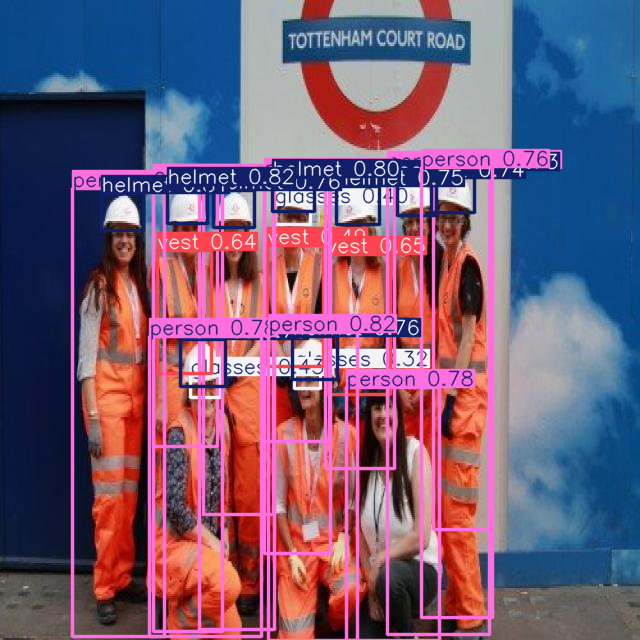

In [12]:
test_images = [f for f in os.listdir(TEST_IMAGES_DIR) if f.lower().endswith((".jpg", ".jpeg", ".png"))]

if not test_images:
    raise FileNotFoundError(f"No se encontraron imágenes en {TEST_IMAGES_DIR}")

image_path = TEST_IMAGES_DIR / test_images[0]
print(f"Probando con: {image_path}")
results = model.predict(str(image_path), save=True, imgsz=640)
results[0].show()

## Validar

In [13]:
metrics = model.val()
print(metrics)

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1452.6±834.3 MB/s, size: 41.0 KB)
val: Scanning /content/dataset/valid/labels.cache... 742 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 742/742 311.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 47/47 5.4it/s 8.6s0.1s
                   all        742       3828      0.753      0.698      0.746      0.494
                 boots        288        652      0.905      0.761      0.868      0.602
              earmuffs        218        344      0.651      0.554      0.608      0.372
               glasses        222        264       0.74      0.629      0.712      0.366
                gloves        150        310      0.355      0.458      0.371      0.203
                helmet        482        802       0.89       0.89      0.905      0.645
                person        556  

## Exportar

In [14]:
model.export(format="onnx")
model.export(format="torchscript")
model.export(format="tflite")

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from '/content/runs/detect/train-3/weights/best.pt' with input shape (1, 3, 512, 512) BCHW and output shape(s) (1, 11, 5376) (5.9 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 320ms
Prepared 4 packages in 7.47s
Installed 4 packages in 301ms
 + colorama==0.4.6
 + onnx==1.21.0
 + onnxruntime-gpu==1.25.0
 + onnxslim==0.1.91

requirements: AutoUpdate success ✅ 8.7s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.21.0 opset 20...
ONNX: slimming with onnxslim 0.1.91...
ONNX: export success ✅ 10.2s, saved as '/content/r

'/content/runs/detect/train-3/weights/best_saved_model/best_float32.tflite'

## Guardar modelos ONNX y TFLite en Google Drive

Este bloque monta Google Drive y copia las versiones exportadas de `best.onnx` y `best_float32.tflite` a una carpeta de Drive para conservarlas.

In [15]:
if not IS_COLAB:
    print("Este bloque está pensado para Google Colab.")
else:
    from google.colab import drive
    from shutil import copy2

    DRIVE_EXPORT_DIR = Path("/content/drive/MyDrive/modelos_ppe_yolo")

    drive.mount("/content/drive", force_remount=False)
    DRIVE_EXPORT_DIR.mkdir(parents=True, exist_ok=True)

    onnx_candidates = sorted(
        Path("/content/runs/detect").glob("train*/weights/best.onnx"),
        key=lambda p: p.stat().st_mtime,
        reverse=True,
    )
    tflite_candidates = sorted(
        Path("/content/runs/detect").glob("train*/weights/best_saved_model/*.tflite"),
        key=lambda p: p.stat().st_mtime,
        reverse=True,
    )

    if not onnx_candidates:
        raise FileNotFoundError("No se encontró ningún archivo best.onnx exportado.")
    if not tflite_candidates:
        raise FileNotFoundError("No se encontró ningún archivo .tflite exportado.")

    latest_onnx = onnx_candidates[0]
    latest_tflite = tflite_candidates[0]
    run_name = latest_onnx.parents[1].name

    drive_onnx_path = DRIVE_EXPORT_DIR / f"{run_name}_best.onnx"
    drive_tflite_path = DRIVE_EXPORT_DIR / f"{run_name}_{latest_tflite.name}"

    copy2(latest_onnx, drive_onnx_path)
    copy2(latest_tflite, drive_tflite_path)

    print(f"Modelo ONNX guardado en: {drive_onnx_path}")
    print(f"Modelo TFLite guardado en: {drive_tflite_path}")

Mounted at /content/drive
Modelo ONNX guardado en: /content/drive/MyDrive/modelos_ppe_yolo/train-3_best.onnx
Modelo TFLite guardado en: /content/drive/MyDrive/modelos_ppe_yolo/train-3_best_float16.tflite
